In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Cargar los datos (apuntamos a donde lo moviste antes)
archivo = 'airflow/dags/tripadvisor_european_restaurants.csv'
print(f"\n--- INICIANDO RADIOGRAFÍA DE: {archivo} ---\n")

try:
    datos_completos = pd.read_csv(archivo)
except FileNotFoundError:
    print("ERROR: No encontrado")
    exit()

# 2. Tamaño del dataset
print("TAMAÑO DEL DATASET:")
print(f"Total de restaurantes (filas): {datos_completos.shape[0]}")
print(f"Total de variables (columnas): {datos_completos.shape[1]}\n")


--- INICIANDO RADIOGRAFÍA DE: airflow/dags/tripadvisor_european_restaurants.csv ---



/tmp/ipykernel_4168/3474716988.py:6: DtypeWarning: Columns (0: region) have mixed types. Specify dtype option on import or set low_memory=False.
  datos_completos = pd.read_csv(archivo)


TAMAÑO DEL DATASET:
Total de restaurantes (filas): 1083397
Total de variables (columnas): 42



COmo tenemos demasidas observaciones, seleccionamos una muestra aleatoria representativa de un 40% de los datos originales para mejor facilidad computacional.

In [3]:
datos = datos_completos.sample(frac = 0.4, random_state=42)
print(f"Tamaño de la muestra de trabajo: {datos.shape[0]} filas.")
del datos_completos

Tamaño de la muestra de trabajo: 433359 filas.


**VARIABLE TEMPORAL**

En futuras prácticas se simularán estos datos como datos en streaming, para facilitar esta práctica a futuro, hemos incorporado una nueva variable llamada `timestamp` que establece un momento a cada observación.

El siguiente código asigna a la primera observación el momento "01-01-2021 00:00:00" y va sumando un segundo a cada observación, sin que ninguna observación tenga el mismo timestamp.

In [5]:
# Fecha inicial
fecha_inicio = pd.Timestamp("2021-01-01 00:00:00")

# Crear la nueva columna timestamp según el orden de las filas
datos["timestamp"] = fecha_inicio + pd.to_timedelta(range(len(datos)), unit="s")
# Mostrar las primeras filas para verificar
print("Primeras filas con la nueva columna timestamp:")
print(datos[["timestamp"]].head())

Primeras filas con la nueva columna timestamp:
                 timestamp
962380 2021-01-01 00:00:00
746926 2021-01-01 00:00:01
556479 2021-01-01 00:00:02
511831 2021-01-01 00:00:03
76556  2021-01-01 00:00:04


Estamos suponiendo que las observaciones se encuantran en su fila del dataset por simple azar.

Somos conscientes de que sí exisitiera en el dataset una razón por la cual cada observacion esta en una fila o en otra (por ejemplo, por orden alfavetico), este método podría alterar las prácticas en streaming del futuro. Seremos conscientes de esto en el futuro a la hora de interpretar los resultados y tomaremos sus respectivas contramedidas.

**NULOS**

/tmp/ipykernel_4168/2855402691.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=nulos_filtrados.values, y=nulos_filtrados.index, palette="Reds_r")


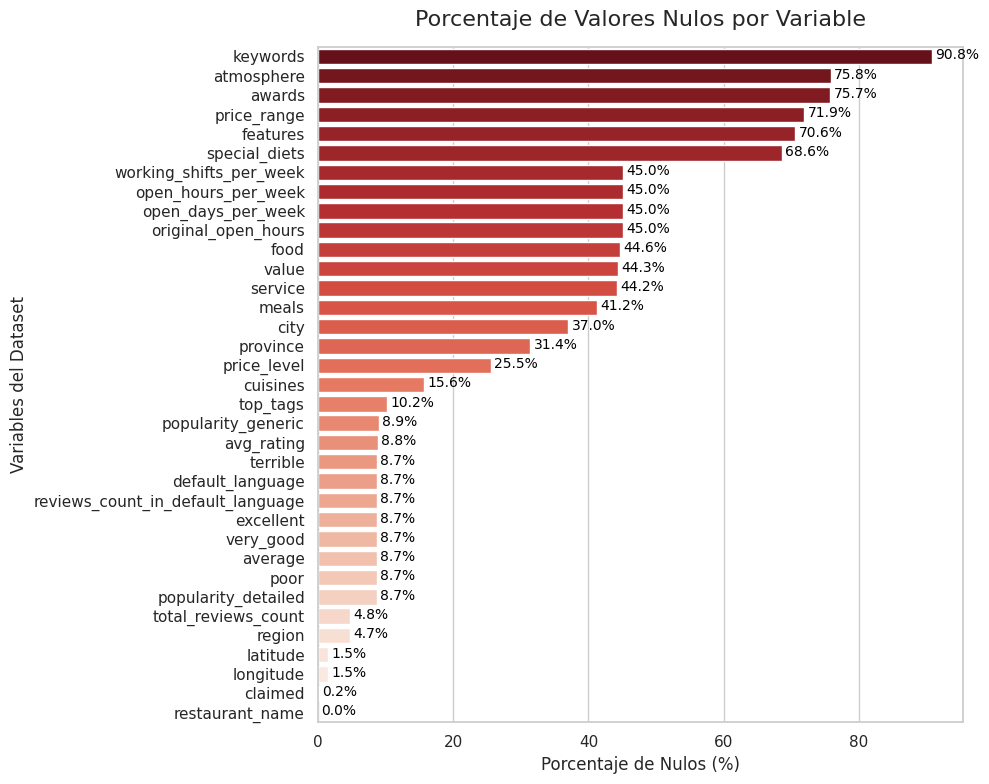

In [4]:
# 1. Calcular el porcentaje de nulos
nulos_porcentaje = (datos.isnull().sum() / len(datos)) * 100

# 2. Filtrar solo las que tienen > 0% de nulos y ordenarlas de mayor a menor
nulos_filtrados = nulos_porcentaje[nulos_porcentaje > 0].sort_values(ascending=False)

# 3. Configurar el lienzo (ancho x alto en pulgadas)
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid") # Fondo limpio con cuadrícula

# 4. Crear el gráfico (Barras horizontales)
# Usamos una paleta rojiza ('Reds_r') para dar sensación de "alerta" en los nulos más altos
ax = sns.barplot(x=nulos_filtrados.values, y=nulos_filtrados.index, palette="Reds_r")

# 5. Títulos y etiquetas descriptivas
plt.title('Porcentaje de Valores Nulos por Variable', fontsize=16, pad=15)
plt.xlabel('Porcentaje de Nulos (%)', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)

# 6. El toque Senior: Escribir el % exacto al lado de cada barra
for i, v in enumerate(nulos_filtrados.values):
    ax.text(v + 0.5, i + 0.15, f"{v:.1f}%", color='black', fontsize=10)

# Ajustar los márgenes para que no se corte nada y mostrar
plt.tight_layout()
plt.show()

Cómo ya veíamos en la propia web de kaggle, los datos presentan una gran cantidad de nulos en gran parte de las variables. Más tarde gestionaremos los nulos por cada variable.

**TIPOS DE LOS DATOS**

In [14]:
# 4. Tipos de datos
print("TIPOS DE DATOS DE LAS COLUMNAS:")
print(datos.dtypes)
print("\n")

TIPOS DE DATOS DE LAS COLUMNAS:
restaurant_link                          str
restaurant_name                          str
original_location                        str
country                                  str
region                                   str
province                                 str
city                                     str
address                                  str
latitude                             float64
longitude                            float64
claimed                                  str
awards                                   str
popularity_detailed                      str
popularity_generic                       str
top_tags                                 str
price_level                              str
price_range                              str
meals                                    str
cuisines                                 str
special_diets                            str
features                                 str
vegetarian_friendly    

Con este primer vistazo al tipo de datos, vemos que existen múltiples de posibles transformaciones de variables con fin de reducir la dimensionalidad.

Por ejemplo, las variables `terrible`, `poor`, `average`, `very_good` y `excelent` parecen representar la misma información: Lo que le ha parecido al cliente la experiencia en el restaurante, como las estrellas típicas de google.

Nos damos cuenta que existe una variable en el dataset (`avg_rating`) que resume estas 5 variables en una media ponderada de las categorías.